# Pooled spectral responses by stimulus orientation (45° vs 135°)

Grand power spectra of the LFP response to the two grating images, pooled over *every
individual stimulus presentation* across the analysis conditions (not a contrast — just
the two pooled responses side by side, per visual area).

**Why orientation, not the x/Y labels.** The two images are gratings at **45°** and
**135°**. Which orientation plays the "standard/x" role is *counterbalanced across mice*
(some have x=135°, others x=45°), and role is perfectly confounded with orientation
*within* a mouse. Pooling by the paradigm label would cancel orientation across mice and
leave a standard-vs-deviant (expectation) contrast; pooling by the ground-truth
`orientation` field compares the two physical gratings, with oddball role balancing out.
This notebook does the latter. (For reference, x=135° in 8 mice and x=45° in 6.)

**Structure of a trial** (see `passiveglo-paradigm-structure` memory): 5 interval rows —
4 gratings (`stim0..stim3`, the deviant last at `stim3`) plus a trailing blank/gray
(`stim4`, `orientation = nan`). We tag every grating by its orientation and drop the
blank.

**Scope.** Trials belonging to the analysis conditions (`CONDITIONS` below); `lonaive` is
a relabeled subset of `lo_gloexp`, so those presentations are already included and are not
counted twice. Set `RESTRICT_TO_CONDITIONS = False` to instead pool every non-blank
presentation in the session.

The notebook (1) re-epochs each subject's raw LFP aligned to every grating onset, tagged
by orientation; (2) pools into `ori_45` / `ori_135` samplings and pickles them per
subject; (3) computes a `PowerSpectrum` per orientation per subject; (4) plots the pooled
45°-vs-135° spectra per area. Requires the dataset mounted at `/mnt/data/000253`.

In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: OMPI_MCA_btl_sm_backing_directory=/mnt/data/tmp_storage
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import glob
import functools
import logging
import math
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import pynwb
import pandas as pd
import quantities as pq
import scipy

import epych
from epych.statistics import alignment

[striatum:488959] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/1426325504/shared_mem_cuda_pool.striatum could be created.
[striatum:488959] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [5]:
logging.basicConfig(level=logging.INFO)

## Configuration

In [6]:
# Physical grating orientations (degrees) = the two images.
ORIENTATIONS = [45, 135]
ORIENTATION_TITLES = {45: "45°", 135: "135°"}

# Analysis-condition scope: a stimulus is pooled only if its trial belongs to one of these
# (condition columns flag the trial's oddball row). lonaive is a subset of lo_gloexp, so it
# is already covered here. Set RESTRICT_TO_CONDITIONS = False to pool every non-blank
# presentation in the session instead.
CONDITIONS = ["go_gloexp", "lo_gloexp", "go_seqctl", "lo_rndctl", "igo_seqctl", "go_rndctl"]
RESTRICT_TO_CONDITIONS = True

# Window cut around each individual stimulus onset.
PRESTIM_SECONDS = 0.1 * pq.second
POSTSTIM_SECONDS = 0.5 * pq.second

# Per-orientation guard: when False, only pools missing on disk are (re)epoched.
FORCE_RECOMPUTE = False

anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [7]:
NWB_SUBJECTS = glob.glob('/mnt/data/000253/sub-*/')

In [8]:
PILOT_FILES = []
REQUIRED_PROBES = 6

## Interval helpers and raw-LFP loading

Copied from `epoching.ipynb` except for `passiveglo_orientation_epochs`, which builds one
`ori_45` / `ori_135` epoch per grating from the ground-truth `orientation` field (the
trailing blank has `orientation = nan` and is dropped).

In [9]:
def trial_intervals(intervals):
    trial_nums = intervals['trial_num'][:].astype(int)
    trials = np.unique(trial_nums)
    startstops = []
    for trial in trials:
        indices = np.nonzero(trial_nums == trial)[0]
        startstops.append((intervals['start_time'][indices[0]], intervals['stop_time'][indices[-1]]))
    return np.array(startstops)

In [10]:
def passiveglo_orientation_epochs(glo_intervals):
    """Epoch table with a `trial` epoch per trial plus an `ori_<deg>` epoch per grating,
    labelled from the ground-truth `orientation` field. Blank/gray rows (orientation nan)
    are dropped. When RESTRICT_TO_CONDITIONS, only trials flagged by a CONDITIONS column
    are kept (columns flag the trial's oddball row, so any-flagged-row => in scope)."""
    epochs = {"start": [], "end": [], "type": []}

    trials = trial_intervals(glo_intervals)
    epochs["start"] += list(trials[:, 0].squeeze())
    epochs["end"] += list(trials[:, 1].squeeze())
    epochs["type"] += ["trial"] * trials.shape[0]

    trial_nums = np.asarray(glo_intervals['trial_num'][:]).astype(int).squeeze()
    starts = np.asarray(glo_intervals['start_time'][:]).squeeze()
    stops = np.asarray(glo_intervals['stop_time'][:]).squeeze()
    orientation = np.asarray(glo_intervals['orientation'][:]).astype(float).squeeze()
    cond_cols = {c: np.asarray(glo_intervals[c][:]).astype(bool).squeeze()
                 for c in CONDITIONS if c in glo_intervals}

    blanks = unscoped = unknown = 0
    for trial in np.unique(trial_nums):
        rows = np.nonzero(trial_nums == trial)[0]
        if RESTRICT_TO_CONDITIONS and not any(cond_cols[c][rows].any() for c in cond_cols):
            unscoped += 1
            continue
        for row in rows:
            o = orientation[row]
            if np.isnan(o):
                blanks += 1
                continue
            deg = int(round(o))
            if deg not in ORIENTATIONS:
                unknown += 1
                continue
            epochs["start"].append(float(starts[row]))
            epochs["end"].append(float(stops[row]))
            epochs["type"].append("ori_%d" % deg)

    logging.info("Epoch table: %d blank rows dropped, %d out-of-scope trials skipped, %d unknown-orientation rows skipped",
                 blanks, unscoped, unknown)
    return pd.DataFrame(data=epochs, columns=list(epochs.keys()))

In [11]:
def probe_lfps(nwb_files, electrodes):
    signals = {}
    for p, nwb_file in enumerate(nwb_files):
        with pynwb.NWBHDF5IO(path=nwb_file, mode="r") as io:
            nwb = io.read()

            probe_lfp = "probe_%d_lfp_data" % p
            lfps = nwb.acquisition[probe_lfp]
            timestamps = lfps.timestamps[:] * pq.second
            dt = (timestamps[1:] - timestamps[:-1]).mean()
            if dt > 1.:
                raise ValueError('Invalid timestamps!')

            probe = list(nwb.electrode_groups.keys())[0]
            probe_electrodes = electrodes["group_name"][:] == probe
            channels = {
                "horizontal": electrodes["probe_horizontal_position"][probe_electrodes] * pq.mm,
                "id": electrodes["id"][probe_electrodes],
                "location": electrodes["location"][probe_electrodes],
                "vertical": electrodes["probe_vertical_position"][probe_electrodes] * pq.mm,
            }
            channels = {k: v[lfps.electrodes['local_index'][:]] for k, v in channels.items()}
            probe_channels = pd.DataFrame(data=channels, columns=["horizontal", "location", "vertical"], index=channels['id'])
            signals[probe] = epych.signals.lfp.RawLfp(probe_channels, lfps.data[:] * pq.volt, dt, timestamps, channels_dim=1, time_dim=0)
    return signals

In [12]:
def subjectdir_recording(subject_dir):
    passive_glo = scipy.io.loadmat(subject_dir + 'passiveglo_task_data.mat')
    epochs = passiveglo_orientation_epochs(passive_glo)
    units = {"start": pq.second, "end": pq.second}
    ogen_nwb = glob.glob(subject_dir + '/sub-*_ogen.nwb')[0]
    with pynwb.NWBHDF5IO(path=ogen_nwb, mode="r") as io:
        nwb = io.read()
        electrodes = {}
        electrodes['group_name'] = nwb.electrodes.group_name[:]
        electrodes['id'] = nwb.electrodes.id[:]
        electrodes['location'] = nwb.electrodes.location[:]
        electrodes['probe_horizontal_position'] = nwb.electrodes.probe_horizontal_position[:] * pq.mm
        electrodes['probe_vertical_position'] = nwb.electrodes.probe_vertical_position[:] * pq.mm

    nwb_files = sorted(glob.glob(subject_dir + '/sub-*_ses-*_probe-*.nwb'))
    nwb_files = [nwbf for nwbf in nwb_files if "test" not in nwbf]
    if len(nwb_files) < REQUIRED_PROBES:
        PILOT_FILES.append(subject_dir)
        return None

    try:
        signals = probe_lfps(nwb_files, electrodes)
        return epych.recording.RawRecording(epochs, pd.DataFrame(columns=["trial"]).set_index("trial"), units, **signals)
    except ValueError as verr:
        if verr.args == ('Invalid timestamps!',):
            return None
        raise verr

## Epoch every grating, pooled by orientation

Each grating is cut aligned to its own onset (`outer_epochs=None`), pooled into `ori_45` /
`ori_135` samplings, and pickled per subject.

In [13]:
for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
    subject = subject_dir.split('/')[-2]
    pending = [deg for deg in ORIENTATIONS
               if FORCE_RECOMPUTE or not os.path.exists(subject_dir + "/ori_%d" % deg)]
    if not pending:
        logging.info("All orientation pools already epoched for %s; skipping", subject_dir)
        continue

    recording = subjectdir_recording(subject_dir)
    if recording is None:
        continue

    for deg in pending:
        ori_epochs = recording.intervals["type"] == ("ori_%d" % deg)
        sampling = recording.epoch(ori_epochs, None, PRESTIM_SECONDS, POSTSTIM_SECONDS)
        os.makedirs(subject_dir + "/ori_%d" % deg, exist_ok=True)
        sampling.pickle(subject_dir + "/ori_%d" % deg)
        n = len(sampling.trials)
        del sampling
        logging.info("Epoched %d %d-deg gratings in %s", n, deg, subject_dir)
    del recording

INFO:root:Epoch table: 991 blank rows dropped, 216 out-of-scope trials skipped, 0 unknown-orientation rows skipped
/home/eli/miniforge3/envs/ephys/lib/python3.12/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.6.0 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/eli/miniforge3/envs/ephys/lib/python3.12/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/eli/miniforge3/envs/ephys/lib/python3.12/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.3.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/home/eli/miniforge3/e

## Power spectra per orientation per subject

Same alignment + `PowerSpectrum` pipeline as `aligned_subject_spectra.ipynb`. The saved
aligner uses global-k indexing (`AREA_COUNTER[area]` incremented per subject), so the
counter is reset once per orientation pool.

In [14]:
aligner = epych.statistics.alignment.AlignmentSummary.unpickle("/mnt/data/000253/visual_alignment")
AREA_COUNTER = collections.Counter()

In [15]:
def visual_align(signal):
    visual = signal.select_channels(["VIS" in loc for loc in signal.channels.location]).median_filter()
    area = alignment.location_prefix(None, visual)
    result = aligner.stats[area].align(AREA_COUNTER[area], visual)
    AREA_COUNTER[area] += 1
    return result

In [16]:
def samplings(subject_dir, deg):
    subject = subject_dir.split('/')[-2]
    sampling = epych.recording.Sampling.unpickle(subject_dir + "/ori_%d" % deg).smap(
        lambda sig: visual_align(sig)
    )
    logging.info("Loaded LFPs for %d-deg gratings in subject %s", deg, subject)
    yield sampling
    del sampling

In [17]:
def initialize_spectrum(key, signal):
    return epych.statistics.spectrum.PowerSpectrum(signal.df, signal.channels, signal.f0, taper="hann", time_window=0.500)

In [18]:
summaries = {deg: {} for deg in ORIENTATIONS}

for deg in ORIENTATIONS:
    AREA_COUNTER = collections.Counter()
    for s, subject_dir in enumerate(sorted(NWB_SUBJECTS)):
        subject = subject_dir.split('/')[-2]
        if not os.path.exists(subject_dir + "/ori_%d" % deg):
            continue
        spectrum_path = "%s/spectrum_ori_%d" % (subject_dir, deg)
        if os.path.exists(spectrum_path) and not FORCE_RECOMPUTE:
            summaries[deg][subject] = epych.statistic.Summary.unpickle(
                spectrum_path, epych.statistics.spectrum.PowerSpectrum)
        else:
            summaries[deg][subject] = epych.statistic.Summary(alignment.location_prefix, initialize_spectrum)
            summaries[deg][subject].calculate(samplings(subject_dir, deg))
            summaries[deg][subject].pickle(spectrum_path)
        logging.info("Analyzed %d-deg spectra in subject %s", deg, subject)

INFO:root:Loaded LFPs for 45-deg gratings in subject sub-621890
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [01:09<00:00,  2.77s/it]
INFO:root:Analyzed 45-deg spectra in subject sub-621890
INFO:root:Loaded LFPs for 45-deg gratings in subject sub-632485
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:20<00:00,  2.76s/it]
INFO:root:Analyzed 45-deg spectra in subject sub-632485
INFO:root:Loaded LFPs for 45-deg gratings in subject sub-632487
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [01:20<00:00,  2.77s/it]
INF

## Separate aperiodic / oscillatory components

In [19]:
aperiodics = {deg: {subj: {} for subj in summaries[deg]} for deg in ORIENTATIONS}
oscillatories = {deg: {subj: {} for subj in summaries[deg]} for deg in ORIENTATIONS}
freqs_by_area = {}

for deg in ORIENTATIONS:
    for subject in summaries[deg]:
        for area in summaries[deg][subject].stats:
            oscillatory, _, aperiodic = summaries[deg][subject].stats[area].oscillatory(space="log")
            aperiodics[deg][subject][area] = np.power(10, aperiodic)
            oscillatories[deg][subject][area] = oscillatory.data.magnitude
            freqs_by_area.setdefault(area, oscillatory.freqs.magnitude)
            logging.info("Decomposed %d-deg spectrum, subject %s, area %s", deg, subject, area)

INFO:root:Decomposed 45-deg spectrum, subject sub-621890, area VISam
INFO:root:Decomposed 45-deg spectrum, subject sub-621890, area VISpm
INFO:root:Decomposed 45-deg spectrum, subject sub-621890, area VISp
INFO:root:Decomposed 45-deg spectrum, subject sub-621890, area VISl
INFO:root:Decomposed 45-deg spectrum, subject sub-621890, area VISrl
INFO:root:Decomposed 45-deg spectrum, subject sub-632485, area VISam
INFO:root:Decomposed 45-deg spectrum, subject sub-632485, area VISpm
INFO:root:Decomposed 45-deg spectrum, subject sub-632485, area VISp
INFO:root:Decomposed 45-deg spectrum, subject sub-632485, area VISl
INFO:root:Decomposed 45-deg spectrum, subject sub-632485, area VISrl
INFO:root:Decomposed 45-deg spectrum, subject sub-632487, area VISam
INFO:root:Decomposed 45-deg spectrum, subject sub-632487, area VISpm
INFO:root:Decomposed 45-deg spectrum, subject sub-632487, area VISp
INFO:root:Decomposed 45-deg spectrum, subject sub-632487, area VIS
INFO:root:Decomposed 45-deg spectrum, sub

## Pooled 45°-vs-135° spectra per area

Two lines per area (45°, 135°), mean ± 2 SEM across subjects. Top = aperiodic component
(log-log), bottom = oscillatory component (dB).

In [20]:
from epych import plotting
from epych.statistics import spectrum

AREA_TITLES = {"VISal": "AL", "VISam": "AM", "VISl": "LM", "VISp": "V1", "VISpm": "PM", "VISrl": "RL"}
BANDS = [spectrum.THETA_BAND, spectrum.ALPHA_BETA_BAND, spectrum.GAMMA_BAND]
BAND_BOUNDS = np.unique(list(spectrum.THETA_BAND) + list(spectrum.ALPHA_BETA_BAND) + list(spectrum.GAMMA_BAND)) * pq.Hz

In [21]:
def pool_by_orientation(component):
    """component[deg][subject][area] (ndarray) -> pooled[area][deg] = (n_freqs, n_subjects),
    each subject reduced to its channel/trial-mean spectrum over the frequency axis."""
    pooled = collections.defaultdict(lambda: collections.defaultdict(list))
    for deg in ORIENTATIONS:
        for subject in component[deg]:
            for area in component[deg][subject]:
                pooled[area][deg].append(component[deg][subject][area].mean(axis=(0, -1), keepdims=True))
    for area in pooled:
        for deg in pooled[area]:
            pooled[area][deg] = np.concatenate(pooled[area][deg], axis=-1).squeeze()
    return pooled

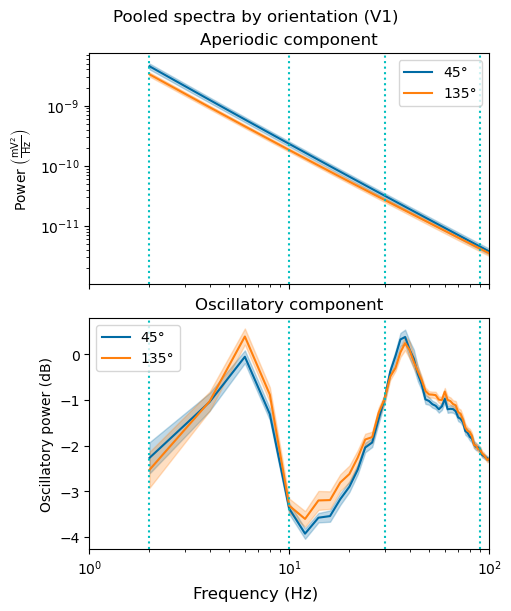

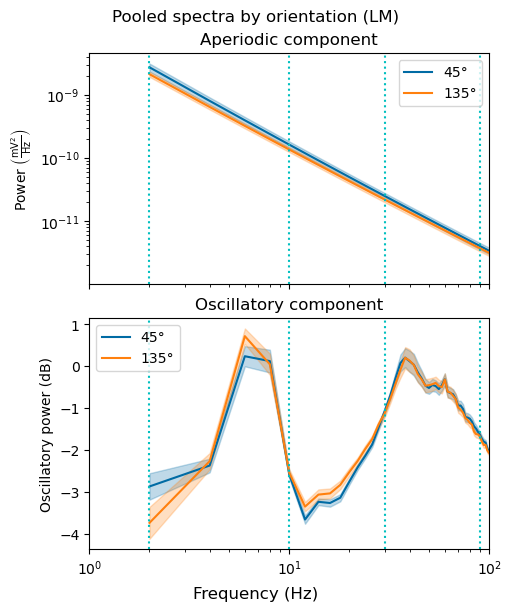

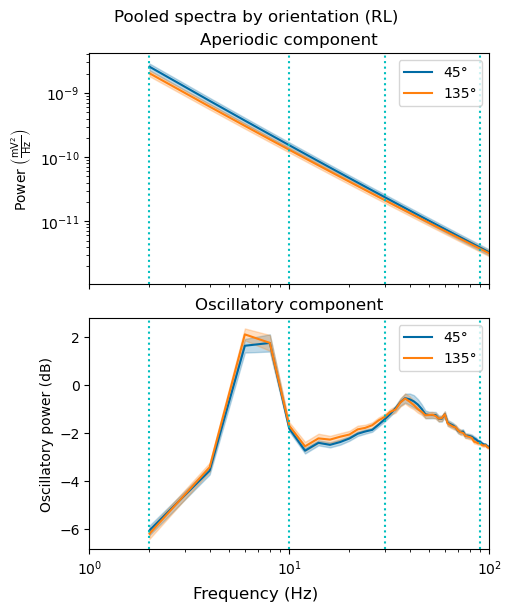

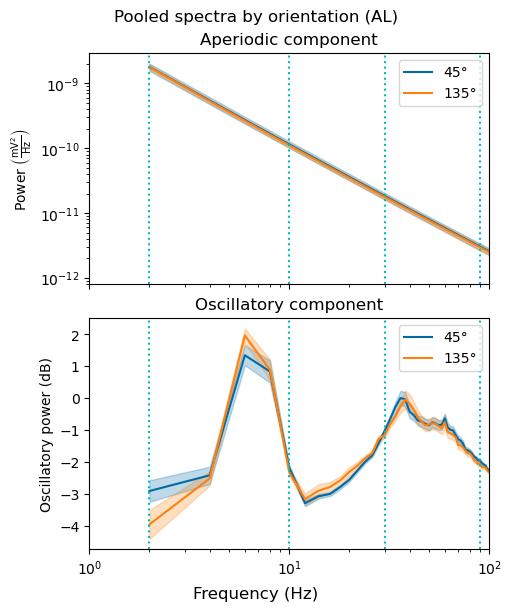

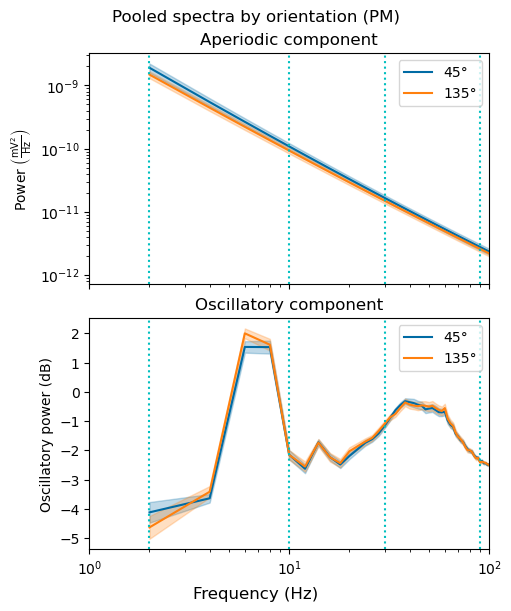

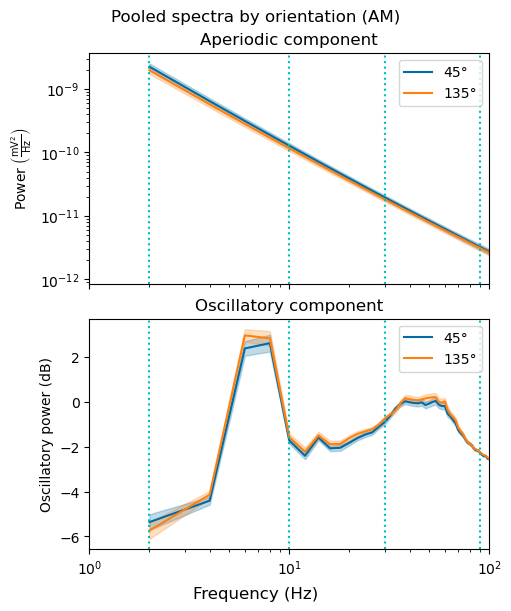

In [22]:
aperiodic_pool = pool_by_orientation(aperiodics)
oscillatory_pool = pool_by_orientation(oscillatories)

for area in anatomical_areas:
    freqs = freqs_by_area.get(area)
    if freqs is None:
        continue
    plt.style.use('tableau-colorblind10')
    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, layout="constrained", figsize=(5, 6))
    fig.suptitle("Pooled spectra by orientation (%s)" % AREA_TITLES[area])

    for deg in ORIENTATIONS:
        plotting.plot_sem(freqs, aperiodic_pool[area][deg], ax=axes[0], axis=-1, sems=2, label=ORIENTATION_TITLES[deg])
    axes[0].set_title("Aperiodic component")
    axes[0].set_ylabel("Power $\\left(\\frac{\\mathrm{mV}^{2}}{\\mathrm{Hz}}\\right)$")
    axes[0].set_yscale("log"); axes[0].set_xlim([0, 90])

    for deg in ORIENTATIONS:
        plotting.plot_sem(freqs, oscillatory_pool[area][deg], ax=axes[1], axis=-1, sems=2, label=ORIENTATION_TITLES[deg])
    axes[1].set_title("Oscillatory component")
    axes[1].set_ylabel("Oscillatory power (dB)")
    axes[1].set_xscale("log"); axes[1].set_xlim([1, 100])

    for ax in axes:
        for boundary in BAND_BOUNDS:
            ax.axvline(boundary, color='c', linestyle=':')
        ax.legend()
    fig.supxlabel("Frequency (Hz)")

    plt.savefig("%s_orientation_spectra.svg" % AREA_TITLES[area])
    plt.savefig("%s_orientation_spectra.png" % AREA_TITLES[area])
    plt.show()